# Two analysts, one dataset, two verdicts

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/bayes-vs-p/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/bayes-vs-p/demo.ipynb)

10,000 users, a one-sample t-test, p = 0.047. Analyst one writes "significant". Analyst two runs the
default Bayesian t-test in JASP and writes "strong evidence of no effect" (BF01 = 12). Both ran their
method correctly. This notebook measures, exactly, when the two verdicts must split, how often, and what
decides it.

1. Calibration - closed form vs quadrature, two JZS integrals vs each other and vs pingouin, raw Monte Carlo
2. Lindley's curve - hold p at 0.05 and grow n
3. The ceiling - the most any normal prior can make of p = 0.05
4. When the null is true - how many "findings" the Bayes factor calls null
5. Negative result - a real but tiny effect: the Bayes factor swaps one error for another
6. Prior sensitivity - one dataset, six Bayes factors
7. Try your own

## The engine

Extracted from `bayes.py` at build time, character for character. The study model is a normal mean with
known unit SD, so z = mean * sqrt(n) is exactly N(delta * sqrt(n), 1). Against H1: delta ~ N(0, tau^2),

BF01 = sqrt(1 + n tau^2) * exp(-z^2/2 * n tau^2 / (1 + n tau^2)),

and "BF01 > k" is the event |z| < a threshold - so every verdict probability is a closed-form normal
integral. Real data use the t statistic and the JZS (Cauchy prior) Bayes factor that JASP, BayesFactor and
pingouin report.

In [1]:
from __future__ import annotations

import warnings
from typing import Dict, List, Sequence

import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate, optimize, stats

ALPHA = 0.05


Z_CRIT = float(stats.norm.isf(ALPHA / 2))


TAU = 1.0  # the unit-information prior: one observation's worth of prior information


R_JZS = float(np.sqrt(2) / 2)  # the default "medium" Cauchy scale in JASP / BayesFactor / pingouin


NS = (10, 30, 100, 300, 1000, 3000, 10000, 100000, 1000000)


TAUS = (0.05, 0.1, 0.2, 0.5, 1.0, 2.0)


MC_REPS = 20000


MC_DESIGNS = ((50, 0.0), (200, 0.1), (1000, 0.0), (1000, 0.07), (2000, 0.05))


Z99 = float(stats.norm.isf(0.005))


def wilson(k: int, n: int, z: float = Z99) -> List[float]:
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return [float(mid - half), float(mid + half)]


def bf01_normal(z: float, n: int, tau: float = TAU) -> float:
    """BF01 for H0: delta = 0 against a N(0, tau^2) alternative, from z = mean * sqrt(n)."""
    s = n * tau * tau
    return float(np.sqrt(1 + s) * np.exp(-0.5 * z * z * s / (1 + s)))


def bf01_normal_by_quadrature(z: float, n: int, tau: float = TAU) -> float:
    """The same Bayes factor as an explicit integral over the prior - the calibration route."""
    lo, hi = z / np.sqrt(n) - 12 / np.sqrt(n), z / np.sqrt(n) + 12 / np.sqrt(n)
    m1, _ = integrate.quad(lambda d: stats.norm.pdf(z, d * np.sqrt(n)) * stats.norm.pdf(d, 0, tau),
                           lo, hi, epsabs=0, epsrel=1e-11, limit=200)
    return float(stats.norm.pdf(z) / m1)


def z_threshold_sq(n: int, k: float, tau: float = TAU) -> float:
    """BF01 > k  <=>  z^2 < this. Negative means BF01 > k is impossible at this n."""
    s = n * tau * tau
    return float((1 + s) / s * (np.log1p(s) - 2 * np.log(k)))


def p_abs_below(a2: float, mu: float) -> float:
    """P(|Z + mu| < sqrt(a2)) for Z standard normal."""
    if a2 <= 0:
        return 0.0
    a = np.sqrt(a2)
    return float(stats.norm.cdf(a - mu) - stats.norm.cdf(-a - mu))


def verdicts(n: int, delta: float, tau: float = TAU) -> Dict[str, float]:
    """Exact probability of each verdict when the true standardised effect is delta."""
    mu = delta * np.sqrt(n)
    zc2 = Z_CRIT ** 2
    below_crit = p_abs_below(zc2, mu)
    t1, t3, t_third = (z_threshold_sq(n, k, tau) for k in (1.0, 3.0, 1 / 3))
    return {
        "n": n, "delta": delta, "tau": tau,
        "p_significant": 1 - below_crit,
        "bf10_over_3": 1 - p_abs_below(t_third, mu),
        "bf01_over_3": p_abs_below(t3, mu),
        # the two analysts disagree: p < alpha AND the Bayes factor favours H0
        "sig_and_bf01_over_1": max(0.0, p_abs_below(t1, mu) - below_crit),
        "sig_and_bf01_over_3": max(0.0, p_abs_below(t3, mu) - below_crit),
    }


def bf01_at_p(p: float, n: int, tau: float = TAU) -> float:
    """Lindley's curve: the Bayes factor of a result whose p-value is held fixed while n grows."""
    return bf01_normal(float(stats.norm.isf(p / 2)), n, tau)


def n_where_p_supports_null(p: float, k: float = 1.0, tau: float = TAU) -> float:
    """Smallest (continuous) n past which a result at exactly this p-value has BF01 >= k.

    BF01 at fixed p is U-shaped in n: it starts at 1, dips to its minimum at n tau^2 = z^2 - 1, then
    grows like sqrt(n). A root search over the whole range can land on the descending crossing (the
    first version did, and reported n = 3.7 for a curve still at 0.58 when n = 10). Bracket from the
    minimum instead, and return n, not the log-n the search runs on (the second defect).
    """
    z = float(stats.norm.isf(p / 2))
    lo = np.log(max(z * z - 1, 1e-9) / tau ** 2)
    return float(np.exp(optimize.brentq(lambda ln: np.log(bf01_at_p(p, np.exp(ln), tau)) - np.log(k), lo, 40)))


def max_bf10_over_normal_priors(z: float) -> Dict[str, float]:
    """The most a N(0, tau^2) alternative can favour H1 at this z: closed form, and by search."""
    closed = float(np.exp((z * z - 1) / 2) / abs(z)) if abs(z) > 1 else 1.0
    res = optimize.minimize_scalar(lambda lt: bf01_normal(z, 1, np.exp(lt)), bounds=(-8, 8), method="bounded",
                                   options={"xatol": 1e-12})
    return {"closed_form": closed, "by_search": float(1 / res.fun), "best_tau_sqrt_n": float(np.exp(res.x))}


def sbb_bound(p: float) -> float:
    """Sellke-Bayarri-Berger (2001): BF10 <= 1 / (-e p ln p) for p < 1/e, over a broad class of alternatives."""
    return float(1 / (-np.e * p * np.log(p)))


def bf10_jzs(t: float, n: int, r: float = R_JZS) -> float:
    """JZS Bayes factor for a one-sample t (Rouder et al. 2009), integrated over g on a log scale."""
    nu = n - 1
    base = (1 + t * t / nu) ** (-(nu + 1) / 2)

    def f(u: float) -> float:
        g = np.exp(u)
        a = 1 + n * g * r * r
        lik = a ** -0.5 * (1 + t * t / (a * nu)) ** (-(nu + 1) / 2)
        prior = (2 * np.pi) ** -0.5 * g ** -1.5 * np.exp(-1 / (2 * g))
        return lik / base * prior * g  # dg = g du

    val, _ = integrate.quad(f, -30, 30, epsabs=0, epsrel=1e-10, limit=400)
    return float(val)


def bf10_jzs_by_delta(t: float, n: int, r: float = R_JZS) -> float:
    """The same Bayes factor as an average of the noncentral-t likelihood over a Cauchy prior on delta."""
    nu, c = n - 1, t / np.sqrt(n)
    w = 10 / np.sqrt(n)
    f = lambda d: stats.nct.pdf(t, nu, d * np.sqrt(n)) * stats.cauchy.pdf(d, 0, r)  # noqa: E731
    with warnings.catch_warnings():  # nct.pdf far in the tails warns; those tails carry ~0 mass
        warnings.simplefilter("ignore")
        parts = [integrate.quad(f, a, b, epsabs=0, epsrel=1e-10, limit=400)[0]
                 for a, b in ((-np.inf, c - w), (c - w, c + w), (c + w, np.inf))]
    return float(sum(parts) / stats.t.pdf(t, nu))


def analyse(x: Sequence[float], r: float = R_JZS) -> Dict[str, float]:
    """One-sample (or paired differences) t: the p-value and the JZS Bayes factor on the same data."""
    x = np.asarray([v for v in x], dtype=float)
    if x.size < 3:
        raise ValueError("need at least 3 values")
    if not np.all(np.isfinite(x)):
        raise ValueError("values must be finite numbers")
    sd = float(np.std(x, ddof=1))
    if sd == 0:
        raise ValueError("all values are identical, so there is no variance to test against")
    n = int(x.size)
    t = float(np.mean(x) / sd * np.sqrt(n))
    bf10 = bf10_jzs(t, n, r)
    return {"n": n, "mean": float(np.mean(x)), "d": float(np.mean(x) / sd), "t": t,
            "p": float(2 * stats.t.sf(abs(t), n - 1)), "bf10": bf10, "bf01": 1 / bf10, "r": r}


def n_for_power(delta: float, key: str, target: float = 0.8, tau: float = TAU) -> int:
    """Smallest n whose verdict probability `key` reaches target (scan up, then bisect the bracket)."""
    lo, hi = 2, 2
    while verdicts(hi, delta, tau)[key] < target:
        lo, hi = hi, hi * 2
        if hi > 10 ** 9:
            raise ValueError("target not reached")
    while hi - lo > 1:
        mid = (lo + hi) // 2
        lo, hi = (lo, mid) if verdicts(mid, delta, tau)[key] >= target else (mid, hi)
    return hi


def calibrate() -> Dict[str, float]:
    """Closed form vs quadrature, g-form JZS vs delta-form JZS vs pingouin, decisions vs scipy."""
    gap_closed = max(abs(np.log(bf01_normal(z, n, tau)) - np.log(bf01_normal_by_quadrature(z, n, tau)))
                     for z in (0.3, 1.96, 3.1) for n in (10, 1000, 100000) for tau in (0.1, 1.0))
    cases = [(t, n) for t in (0.5, 2.1, 3.4) for n in (8, 40, 300)]
    gap_forms = max(abs(np.log(bf10_jzs(t, n)) - np.log(bf10_jzs_by_delta(t, n))) for t, n in cases)
    out = {"max_log_gap_closed_vs_quadrature": float(gap_closed), "max_log_gap_jzs_g_vs_delta": float(gap_forms)}
    try:
        import pingouin as pg

        out["max_log_gap_jzs_vs_pingouin"] = float(max(
            abs(np.log(bf10_jzs(t, n)) - np.log(float(pg.bayesfactor_ttest(t, n, paired=True, r=R_JZS))))
            for t, n in cases))
    except ImportError:
        out["max_log_gap_jzs_vs_pingouin"] = float("nan")
    rng = np.random.default_rng(7)
    mism = 0
    for _ in range(400):
        x = rng.normal(rng.normal(0, 0.3), 1, int(rng.integers(5, 60)))
        a = analyse(x)
        mism += (a["p"] < ALPHA) != (stats.ttest_1samp(x, 0).pvalue < ALPHA)
    out["scipy_decision_mismatches"] = int(mism)
    out["decisions_compared"] = 400
    mx = max_bf10_over_normal_priors(Z_CRIT)
    out["max_bf10_closed_vs_search_gap"] = abs(mx["closed_form"] - mx["by_search"])
    return out


def monte_carlo(reps: int = MC_REPS, seed: int = 11) -> List[Dict]:
    """Raw N(delta, 1) data, z from the sample mean, verdict frequencies vs the exact probabilities."""
    rng = np.random.default_rng(seed)
    out = []
    for n, delta in MC_DESIGNS:
        z = np.empty(reps)
        for i in range(0, reps, 2000):
            k = min(2000, reps - i)
            z[i:i + k] = rng.normal(delta, 1, (k, n)).mean(axis=1) * np.sqrt(n)
        ex = verdicts(n, delta)
        bf = np.sqrt(1 + n) * np.exp(-0.5 * z * z * n / (1 + n))
        freq = {"p_significant": np.abs(z) > Z_CRIT, "bf01_over_3": bf > 3,
                "sig_and_bf01_over_1": (np.abs(z) > Z_CRIT) & (bf > 1)}
        row = {"n": n, "delta": delta}
        for key, hit in freq.items():
            k = int(hit.sum())
            lo, hi = wilson(k, reps)
            row[key] = {"exact": ex[key], "mc": k / reps, "inside_99": bool(lo <= ex[key] <= hi)}
        out.append(row)
    return out


def exemplar(n: int = 10000, delta: float = 0.02) -> Dict:
    """The first seed whose one-sample t lands at 0.03 < p < 0.05: a 'finding' at n = 10,000."""
    for seed in range(1000):
        x = np.random.default_rng(seed).normal(delta, 1, n)
        a = analyse(x)
        if 0.03 < a["p"] < 0.05:
            return {"seed": seed, "true_delta": delta, **a,
                    "bf01_normal_tau1": bf01_normal(a["t"], n, 1.0),
                    "bf01_by_tau": {str(t): bf01_normal(a["t"], n, t) for t in TAUS}}
    raise RuntimeError("no exemplar seed found")

print('engine loaded')

engine loaded


**Resolution of the instrument.** Every study number here is exact and matches `evidence.txt` to the
digit. Only the raw-data Monte Carlo cross-check runs at 4,000 replicates instead of the study's
20,000, so its intervals are about 2.2x wider - lower resolution, not disagreement. `evidence.txt` is
the reference.

## 1. Calibration

In [2]:
print(calibrate())
for r in monte_carlo(4000):
    print(f"n={r['n']:>5} delta={r['delta']:<5} " + "  ".join(
        f"{k}: {r[k]['exact']:.4f}/{r[k]['mc']:.4f} {'in' if r[k]['inside_99'] else 'OUT'}"
        for k in ("p_significant", "bf01_over_3", "sig_and_bf01_over_1")))

{'max_log_gap_closed_vs_quadrature': 1.3322676295501878e-15, 'max_log_gap_jzs_g_vs_delta': 1.5765166949677223e-13, 'max_log_gap_jzs_vs_pingouin': 5.721201290498357e-12, 'scipy_decision_mismatches': 0, 'decisions_compared': 400, 'max_bf10_closed_vs_search_gap': 0.0}
n=   50 delta=0.0   p_significant: 0.0500/0.0455 in  bf01_over_3: 0.8165/0.8273 in  sig_and_bf01_over_1: 0.0048/0.0032 in
n=  200 delta=0.1   p_significant: 0.2930/0.3023 in  bf01_over_3: 0.6371/0.6315 in  sig_and_bf01_over_1: 0.1073/0.1133 in
n= 1000 delta=0.0   p_significant: 0.0500/0.0503 in  bf01_over_3: 0.9701/0.9712 in  sig_and_bf01_over_1: 0.0415/0.0420 in
n= 1000 delta=0.07  p_significant: 0.6001/0.6050 in  bf01_over_3: 0.4833/0.4765 in  sig_and_bf01_over_1: 0.2615/0.2627 in
n= 2000 delta=0.05  p_significant: 0.6088/0.6068 in  bf01_over_3: 0.5355/0.5350 in  sig_and_bf01_over_1: 0.3078/0.3065 in


The closed form and the explicit integral over the prior agree to about 1e-15 in log. The JZS Bayes
factor computed over g and computed over delta (an independent route through the noncentral t) agree to
about 1e-13, and both agree with `pingouin.bayesfactor_ttest` to about 1e-11. The t-test makes the same
decision as `scipy.stats.ttest_1samp` on 400 of 400 datasets. In the 20,000-rep study all 15 Monte Carlo
checks land inside their 99% interval.

## 2. Lindley's curve - p held at exactly 0.05

In [3]:
print(f"{'n':>9}   BF01 tau=1   BF01 JZS   BF01 tau=0.1")
for n in NS:
    t = float(stats.t.isf(ALPHA / 2, n - 1))
    print(f"{n:>9}   {bf01_at_p(0.05, n):>10.3f}   {1 / bf10_jzs(t, n):>8.3f}   {bf01_at_p(0.05, n, 0.1):>12.3f}")
for p in (0.05, 0.01, 0.005):
    print(f"p = {p}: evidence FOR the null (BF01 >= 1) from n = {n_where_p_supports_null(p):,.1f}, "
          f">= 3 from n = {n_where_p_supports_null(p, 3):,.1f}")

        n   BF01 tau=1   BF01 JZS   BF01 tau=0.1
       10        0.579      0.567          0.881
       30        0.868      0.836          0.732
      100        1.501      1.379          0.541
      300        2.558      2.298          0.474
     1000        4.644      4.133          0.579
     3000        8.031      7.127          0.868
    10000       14.654     12.992          1.501
   100000       46.329     41.059          4.644
  1000000      146.500    129.833         14.654
p = 0.05: evidence FOR the null (BF01 >= 1) from n = 41.6, >= 3 from n = 414.5
p = 0.01: evidence FOR the null (BF01 >= 1) from n = 753.5, >= 3 from n = 6,843.2
p = 0.005: evidence FOR the null (BF01 >= 1) from n = 2,633.5, >= 3 from n = 23,772.6


With the unit-information prior a p = 0.05 result is already evidence for the null at n = 42, 3:1 for
it at n = 415, and 130:1 at a million (JZS). Even p = 0.005 - the "redefine significance" threshold -
tips over at n = 2,634. The curve is U-shaped in n: it dips first, then rises like sqrt(n). The first
version of the root finder landed on the dip and returned log n instead of n; both defects have tests.

## 3. The ceiling

In [4]:
mx = max_bf10_over_normal_priors(Z_CRIT)
print(f"best possible normal prior at p = 0.05: BF10 = {mx['closed_form']:.3f}  (search: {mx['by_search']:.3f})")
print(f"Sellke-Bayarri-Berger bound 1/(-e p ln p) at p = 0.05: {sbb_bound(0.05):.3f}")

best possible normal prior at p = 0.05: BF10 = 2.112  (search: 2.112)
Sellke-Bayarri-Berger bound 1/(-e p ln p) at p = 0.05: 2.456


Choose the prior AFTER seeing the data, to flatter H1 as much as possible, and p = 0.05 is still only
2.1 to 1 for an effect. That is the gap the two analysts are arguing across: a p of 0.05 sounds like
"1 in 20", and as evidence it is worth about 2 to 1.

## 4. When the null is true

In [5]:
print(f"{'n':>9}   P(p<.05)   P(BF10>3)   share of 'findings' the BF calls null")
for n in NS:
    v = verdicts(n, 0.0)
    print(f"{n:>9}   {v['p_significant']:.4f}     {v['bf10_over_3']:.4f}      {v['sig_and_bf01_over_1'] / v['p_significant']:.1%}")

        n   P(p<.05)   P(BF10>3)   share of 'findings' the BF calls null
       10   0.0500     0.0246      0.0%
       30   0.0500     0.0159      0.0%
      100   0.0500     0.0087      38.3%
      300   0.0500     0.0049      66.6%
     1000   0.0500     0.0025      82.9%
     3000   0.0500     0.0014      90.7%
    10000   0.0500     0.0007      95.2%
   100000   0.0500     0.0002      98.6%
  1000000   0.0500     0.0001      99.6%


The p-value's false-positive rate is 0.05 at every n - that is its whole contract. The Bayes factor's
chance of a false "evidence for an effect" falls toward zero, and at n = 10,000, 95% of the null's
"significant" results come with a Bayes factor pointing the other way.

## 5. Negative result - a real but tiny effect

n =    1,000   P(p<.05) 0.097   P(BF10>3) 0.009   P(BF01>3, 'no effect') 0.936
n =    5,000   P(p<.05) 0.293   P(BF10>3) 0.031   P(BF01>3, 'no effect') 0.864
n =   10,000   P(p<.05) 0.516   P(BF10>3) 0.084   P(BF01>3, 'no effect') 0.742
n =   20,000   P(p<.05) 0.807   P(BF10>3) 0.258   P(BF01>3, 'no effect') 0.479
n =   50,000   P(p<.05) 0.994   P(BF10>3) 0.806   P(BF01>3, 'no effect') 0.062
n =  100,000   P(p<.05) 1.000   P(BF10>3) 0.996   P(BF01>3, 'no effect') 0.001
n = 1,000,000   P(p<.05) 1.000   P(BF10>3) 1.000   P(BF01>3, 'no effect') 0.000
delta = 0.5: n for 80% -> p-test 32, Bayes factor 45
delta = 0.2: n for 80% -> p-test 197, Bayes factor 339
delta = 0.1: n for 80% -> p-test 785, Bayes factor 1546
delta = 0.05: n for 80% -> p-test 3140, Bayes factor 6939


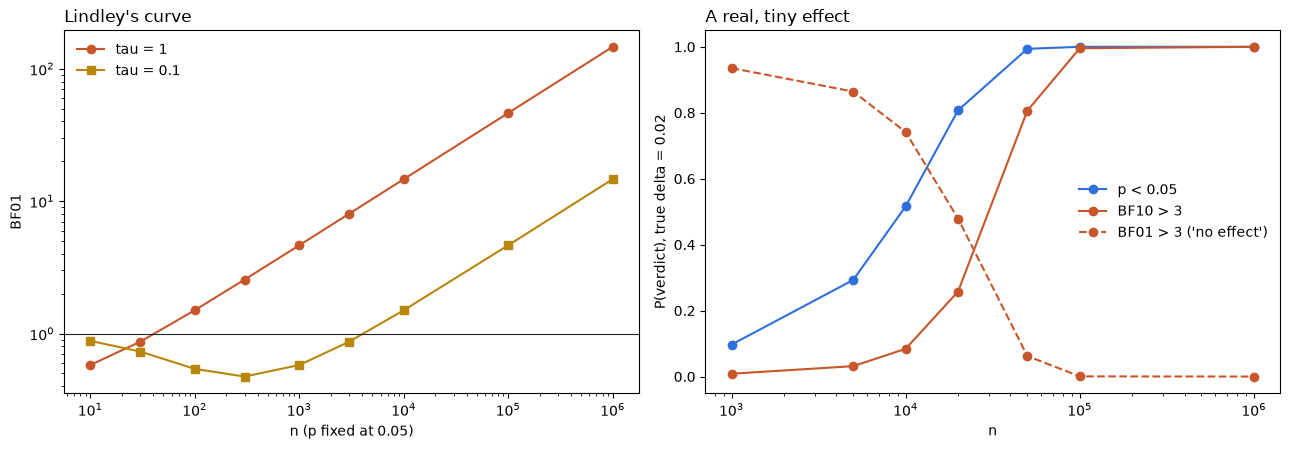

In [6]:
tn = [1000, 5000, 10000, 20000, 50000, 100000, 1000000]
rows = [verdicts(n, 0.02) for n in tn]
for v in rows:
    print(f"n = {v['n']:>8,}   P(p<.05) {v['p_significant']:.3f}   P(BF10>3) {v['bf10_over_3']:.3f}   "
          f"P(BF01>3, 'no effect') {v['bf01_over_3']:.3f}")
for d in (0.5, 0.2, 0.1, 0.05):
    print(f"delta = {d}: n for 80% -> p-test {n_for_power(d, 'p_significant')}, Bayes factor {n_for_power(d, 'bf10_over_3')}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].loglog(NS, [bf01_at_p(0.05, n) for n in NS], "o-", color="#c8562b", label="tau = 1")
axes[0].loglog(NS, [bf01_at_p(0.05, n, 0.1) for n in NS], "s-", color="#b8860b", label="tau = 0.1")
axes[0].axhline(1, color="#1f2733", lw=0.8)
axes[0].set_xlabel("n (p fixed at 0.05)"); axes[0].set_ylabel("BF01"); axes[0].legend(frameon=False)
axes[0].set_title("Lindley's curve", loc="left")
axes[1].semilogx(tn, [v["p_significant"] for v in rows], "o-", color="#2f6fdb", label="p < 0.05")
axes[1].semilogx(tn, [v["bf10_over_3"] for v in rows], "o-", color="#c8562b", label="BF10 > 3")
axes[1].semilogx(tn, [v["bf01_over_3"] for v in rows], "o--", color="#c8562b", label="BF01 > 3 ('no effect')")
axes[1].set_xlabel("n"); axes[1].set_ylabel("P(verdict), true delta = 0.02"); axes[1].legend(frameon=False)
axes[1].set_title("A real, tiny effect", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()

The tempting conclusion from sections 2-4 is "use Bayes factors, they fix p-values". This is where it
fails. The effect here is real (0.02 SD). At n = 20,000 the p-value finds it 81% of the time; the Bayes
factor says "evidence of NO effect" 48% of the time. It is not malfunctioning - on a prior that expects
effects near 1 SD, 0.02 really is closer to zero - but it has traded false positives for false "no
effect" verdicts on small true effects, and it needs 1.4x to 2.2x the sample for the same 80% chance
of finding an effect.

## 6. Prior sensitivity - one dataset, six Bayes factors

In [7]:
ex = exemplar()
print(f"seed {ex['seed']}: n = {ex['n']:,}, observed d = {ex['d']:.4f}, t = {ex['t']:.3f}, p = {ex['p']:.4f}")
print(f"JZS BF01 at the default r = 0.707: {ex['bf01']:.2f}")
for tau, v in ex["bf01_by_tau"].items():
    print(f"  normal prior tau = {tau:<5} BF01 = {v:.3f}")

seed 3: n = 10,000, observed d = 0.0199, t = 1.991, p = 0.0465
JZS BF01 at the default r = 0.707: 12.23
  normal prior tau = 0.05  BF01 = 0.759
  normal prior tau = 0.1   BF01 = 1.413
  normal prior tau = 0.2   BF01 = 2.774
  normal prior tau = 0.5   BF01 = 6.900
  normal prior tau = 1.0   BF01 = 13.790
  normal prior tau = 2.0   BF01 = 27.575


The same 10,000 numbers are 12:1 for "no effect" under the software default, 28:1 under a wide prior,
and 1.3:1 for "an effect" under a prior that expects effects of 0.05 SD. The Bayes factor is not a
property of the data; it is a comparison of the data against a stated alternative, and the alternative
has to be justified from the domain before the data arrive.

## Summary

| claim | what the numbers say |
|---|---|
| "p = 0.05 means strong evidence" | the best any normal prior can do is 2.1 to 1 |
| "a significant result is evidence against the null" | at tau = 1 a p = 0.05 result favours the null from n = 42 |
| "Bayes factors fix this" | a real 0.02 SD effect at n = 20k: 48% chance of 'evidence of no effect' |
| "the Bayes factor is objective" | one dataset: BF01 from 0.76 to 27.6 as the prior width goes 0.05 to 2 |

## 7. Try your own

In [8]:
# values = [0.8, -0.2, 1.4, 0.3, 0.9, -0.5, 1.1, 0.6, 0.2, 1.3]   # one-sample, or after - before
# r = analyse(values, r=0.707)
# print(round(r["p"], 4), round(r["bf01"], 3))
# a reported result: n and p only
# n, p = 50000, 0.03
# t = float(stats.t.isf(p / 2, n - 1)); print("BF01 =", round(1 / bf10_jzs(t, n), 2))
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/bayes-vs-p)

Streamlit version, where you enter your own n and p (or raw values) and move the prior:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`p-value-dance`](../p-value-dance) showed a p-value is itself a random variable;
[`equivalence-test`](../equivalence-test) gives the frequentist route to "no difference";
[`peeking-cost`](../peeking-cost) measured what optional stopping does to a p-value.